In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

In [2]:
def parse_F(series):
    return np.stack([
        np.fromstring(s.strip('[]').replace('\n', ' '), sep=' ')
        if isinstance(s, str) else s
        for s in series.values
    ])

def parse_one(s):
    if isinstance(s, str):
        try:
            return np.array(ast.literal_eval(s))
        except:
            return np.fromstring(s.strip('[]').replace('\n', ' '), sep=' ')
    return np.array(s)

df_statistic = pd.read_csv("dataframe/fidelity_statistic_results_xyz.csv")
time_test = np.linspace(0, 1, len(
    np.fromstring(df_statistic["F"].iloc[0].strip('[]').replace('\n', ' '), sep=' ')
    if isinstance(df_statistic["F"].iloc[0], str) else df_statistic["F"].iloc[0]
))

colors = {"True": "#2166ac", "False": "#d6604d"}
labels = {
    "True": "With SVD correction",
    "False": "Without SVD correction"
}

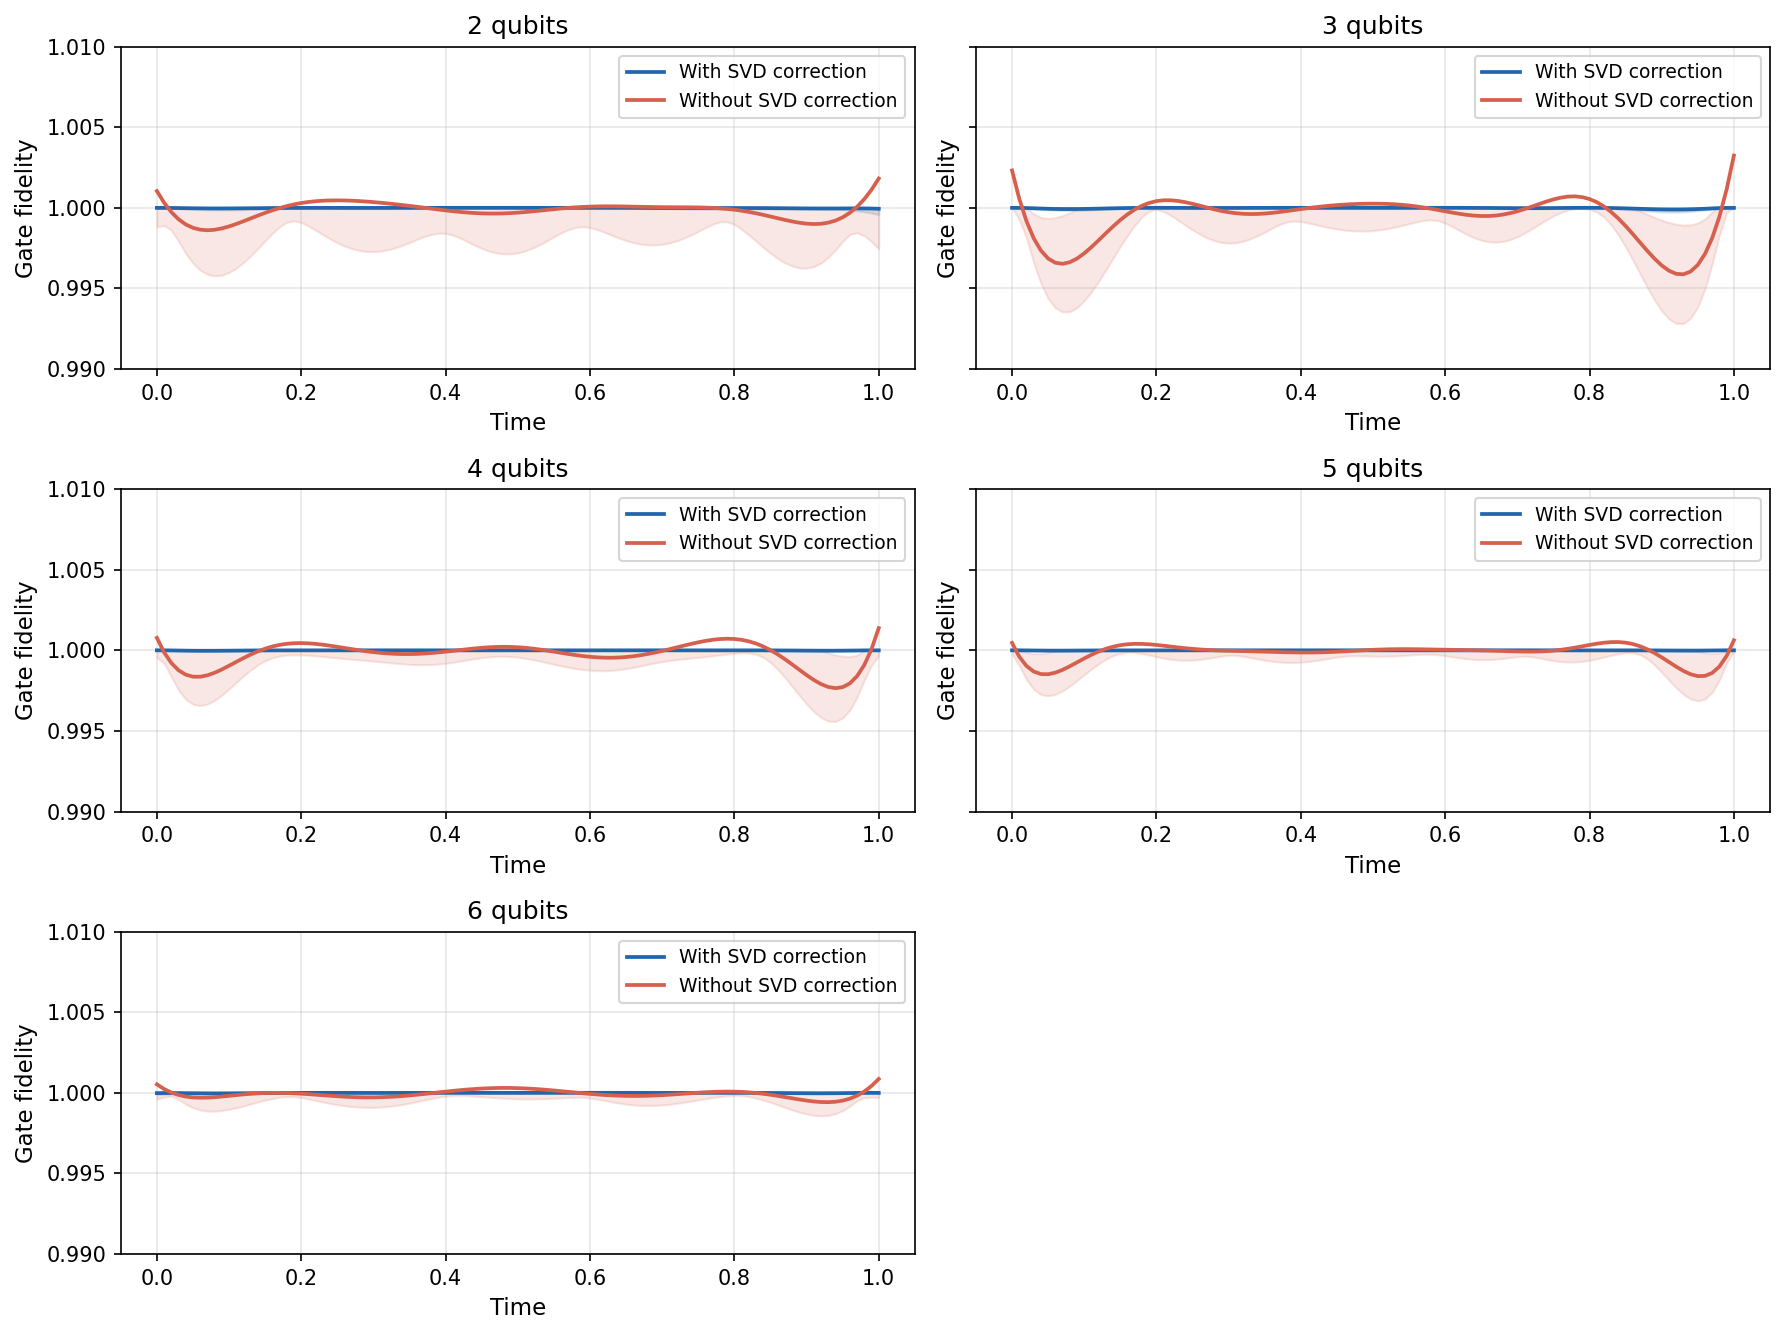

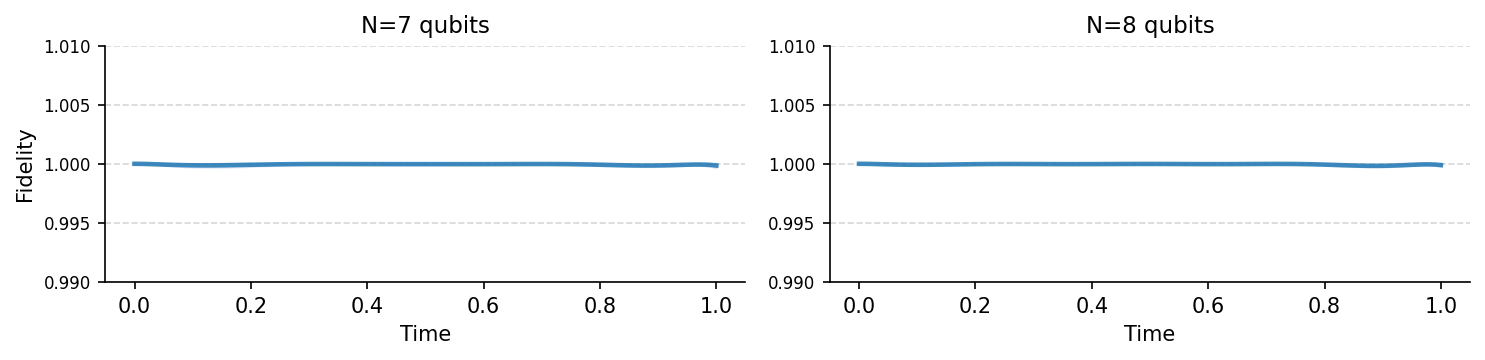

In [3]:
# =========================
# FIGURA 1 : N = 2 -> 6
# =========================

N_values_1 = [2, 3, 4, 5, 6]

fig1, axes1 = plt.subplots(
    3, 2,
    figsize=(12, 9),
    dpi=150,
    sharey=True
)

axes1 = axes1.flatten()

for idx, N in enumerate(N_values_1):

    ax = axes1[idx]

    for close_u in [True, False]:

        df_sub = df_statistic[(df_statistic["N"] == N) & (df_statistic["close_U"] == close_u)]

        if df_sub.empty:
            continue

        F_matrix = parse_F(df_sub["F"])

        mean = F_matrix.mean(axis=0)
        std  = F_matrix.std(axis=0)

        upper = np.clip(mean + std, 0, 1)
        lower = np.clip(mean - std, 0, 1)

        key = str(close_u)

        ax.plot(
            time_test,
            mean,
            color=colors[key],
            label=labels[key],
            lw=1.8
        )

        ax.fill_between(
            time_test,
            lower,
            upper,
            color=colors[key],
            alpha=0.15
        )

    ax.set_title(f"{N} qubits", fontsize=12)
    ax.set_xlabel("Time", fontsize=11)
    ax.set_ylabel("Gate fidelity", fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_ylim([0.99, 1.01])

fig1.delaxes(axes1[-1])
plt.tight_layout()
plt.savefig("figures/fidelity_xyz_N2_to_N6.pdf", bbox_inches="tight")
plt.show()

# =========================
# FIGURA 2 : N = 7 -> 8
# =========================
mean_color = "#1f77b4"
std_color  = "#aec7e8"

N_values_2 = [7, 8]

fig2, axes2 = plt.subplots(1, 2, figsize=(10, 2.5), sharex=True, dpi=150)

for col, N in enumerate(N_values_2):

    ax = axes2[col]

    df_sub = df_statistic[df_statistic["N"] == N]

    if df_sub.empty:
        continue

    F_matrix = parse_F(df_sub["F"])

    mean = F_matrix.mean(axis=0)
    std  = F_matrix.std(axis=0)
    t    = np.linspace(0, 1, len(mean))

    ax.plot(t, mean, linewidth=2.2, color=mean_color, alpha=0.85)
    ax.fill_between(t, mean - std, mean + std, alpha=0.25, color=std_color)

    ax.set_ylim([0.99, 1.01])
    ax.set_title(f"N={N} qubits", fontsize=11)
    ax.set_xlabel("Time", fontsize=10)
    if col == 0:
        ax.set_ylabel("Fidelity", fontsize=10)

    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig2.tight_layout()
plt.savefig("figures/fidelity_xyz_N7_to_N8.pdf", bbox_inches="tight")
plt.show()
plt.close()

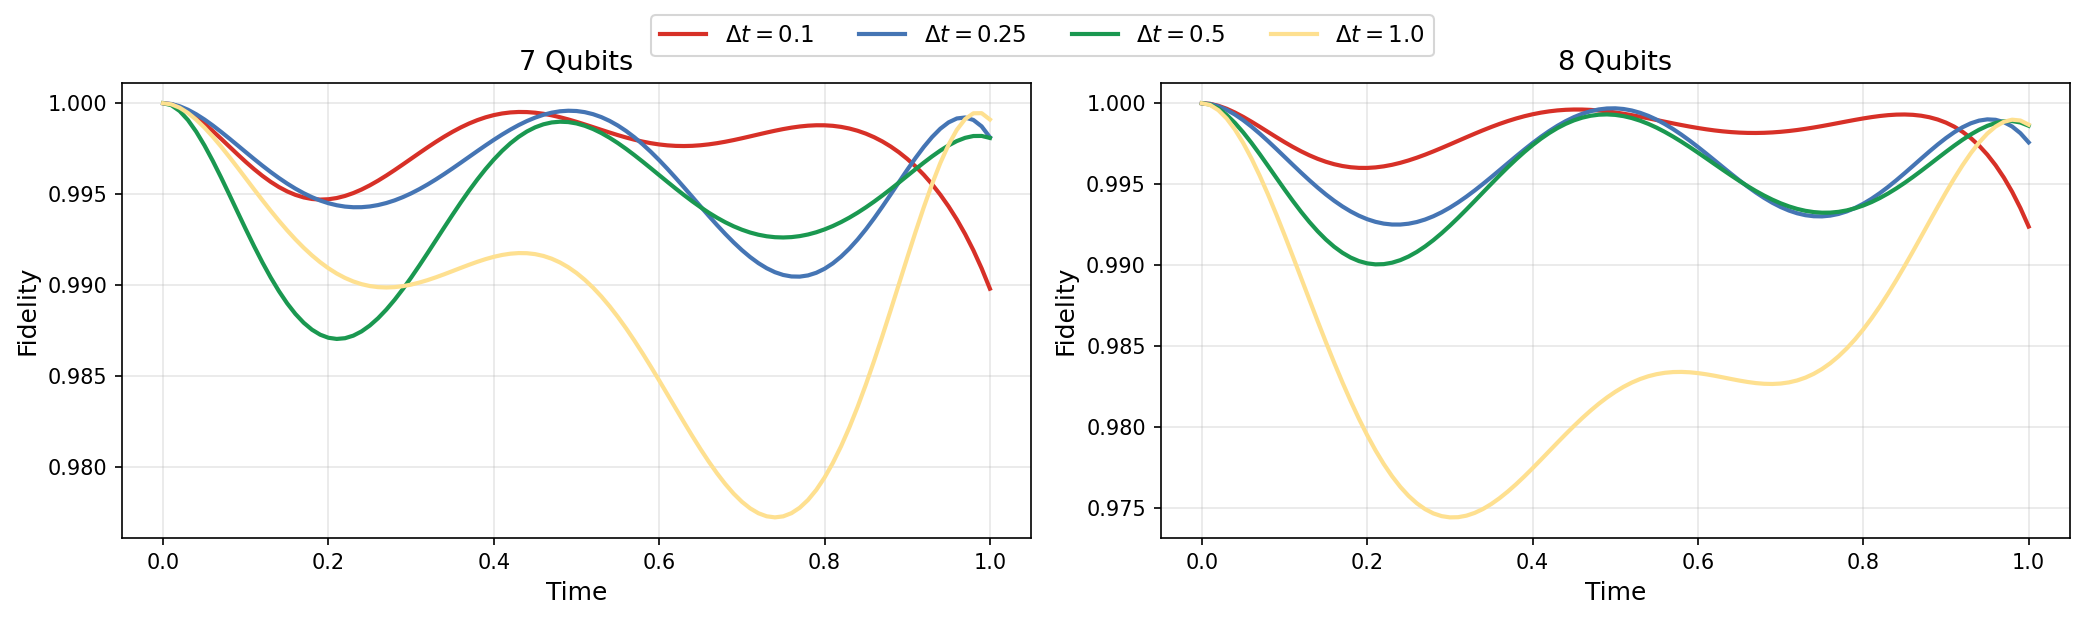

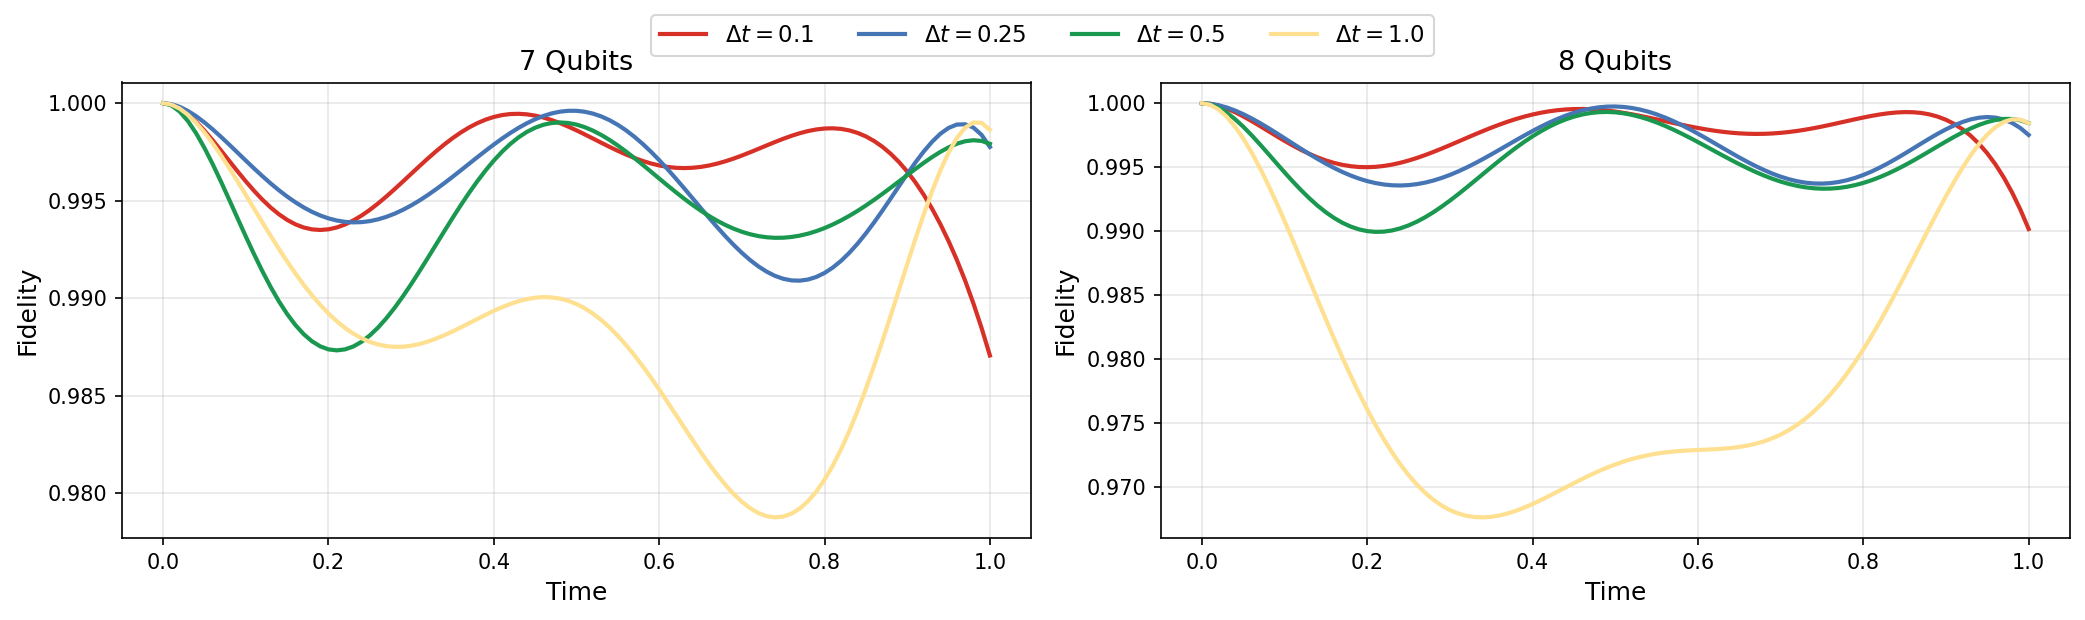

In [4]:
# Colores por dt (igual que la figura de referencia)
dt_colors = {0.1: '#d73027', 0.25: '#4575b4', 0.5: '#1a9850', 1.0: '#fee090'}
dt_labels = {0.1: r'$\Delta t = 0.1$', 0.25: r'$\Delta t = 0.25$',
             0.5: r'$\Delta t = 0.5$', 1.0: r'$\Delta t = 1.0$'}

def plots_fid_xyz(method = "trotter"):
    df_single = pd.read_csv("dataframe/results_xyz_full_loss.csv")
    df_plot = df_single[df_single["method"] == method]

    N_values = sorted(df_plot["N"].unique())
    n_cols = len(N_values)

    fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 4), dpi=150, sharey=False)
    if n_cols == 1:
        axes = [axes]

    for ax, N in zip(axes, N_values):
        df_N = df_plot[df_plot["N"] == N]
        
        # Determinar longitud del array de fidelidades
        sample = parse_one(df_N["fidelity_all"].iloc[0])
        time_test = np.linspace(0, 1, len(sample))
        
        for dt in sorted(dt_colors.keys()):
            row = df_N[df_N["dt"] == dt]
            if row.empty:
                continue
            
            F = parse_one(row["fidelity_all"].iloc[0])
            
            ax.plot(
                time_test, F,
                color=dt_colors[dt],
                label=dt_labels[dt],
                lw=2.0
            )
        
        ax.set_title(f"{N} Qubits", fontsize=13)
        ax.set_xlabel("Time", fontsize=12)
        ax.set_ylabel("Fidelity", fontsize=12)
        ax.grid(alpha=0.3)

    # Leyenda compartida arriba
    handles, labels_leg = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc='upper center', ncol=4,
            fontsize=11, frameon=True, bbox_to_anchor=(0.5, 1.04))

    plt.tight_layout()
    plt.savefig(f"figures/fidelity_xyz_single_{method}.pdf", bbox_inches="tight")
    plt.show()

plots_fid_xyz(method="trotter")
plots_fid_xyz(method="magnus")

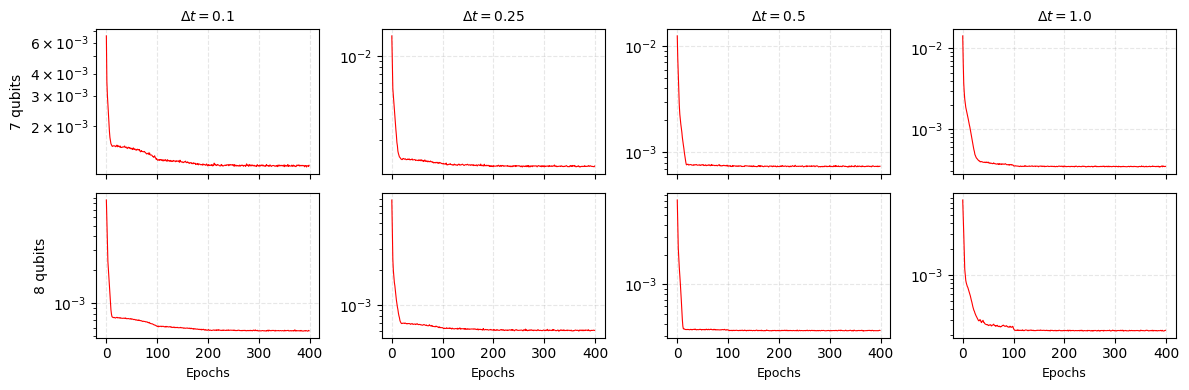

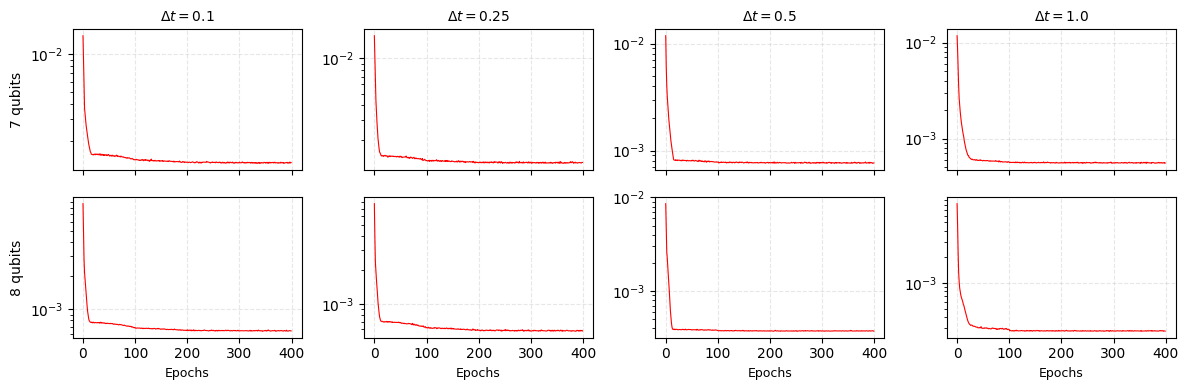

In [5]:
def plot_loss_xyz(method="trotter"):
    Ns     = [7, 8]
    dts    = [0.1, 0.25, 0.5, 1.0]
    rows = len(Ns)
    cols = len(dts)
    df_single = pd.read_csv("dataframe/results_xyz_full_loss.csv")

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2),
                            sharex=True, sharey=False)
    plt.subplots_adjust(hspace=0.25, wspace=0.2)

    for i, N in enumerate(Ns):
        for j, dt in enumerate(dts):

            row = df_single[
                (df_single["N"] == N) &
                (df_single["dt"] == dt) &
                (df_single["method"] == method)
            ]

            ax = axes[i, j]

            if row.empty:
                ax.set_visible(False)
                continue

            loss = parse_one(row["loss"].iloc[0])
            epochs = np.arange(len(loss))

            ax.plot(loss, color="red", linewidth=0.8)
            ax.set_yscale("log")
            ax.grid(True, linestyle='--', alpha=0.3)

            if i == 0:
                ax.set_title(f"$\\Delta t = {dt}$", fontsize=10)
            if j == 0:
                ax.set_ylabel(f"{N} qubits", fontsize=10)
            if i == rows - 1:
                ax.set_xlabel("Epochs", fontsize=9)

    plt.tight_layout()
    plt.savefig(f"figures/loss_variation_7and8_xyz-{method}.pdf",
                dpi=300, bbox_inches='tight')
    plt.show()

plot_loss_xyz(method="trotter")
plot_loss_xyz(method="magnus")